In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

In [54]:
# Load the medical image as grayscale
IMAGE_PATH = r"C:\Users\Neethu\Documents\AMI\x-ray-image-of-human-chest-and-lungs.webp"
img = image.load_img(
    IMAGE_PATH,
    color_mode="grayscale",
    target_size=(128, 128)
)

img_array = image.img_to_array(img)

print("Medical grayscale image shape:", img_array.shape)

Medical grayscale image shape: (128, 128, 1)


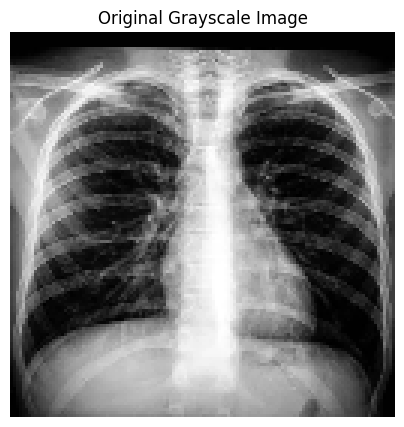

In [ ]:
# Display medical grayscale image
plt.figure(figsize=(5, 5))

plt.imshow(img_array.squeeze(), cmap="gray")
plt.title("Original Medical Grayscale Image")
plt.axis("off")

plt.show()

In [13]:
# Normalize pixel values
img_normalized = img_array / 255.0

print("Minimum pixel value:", img_normalized.min())
print("Maximum pixel value:", img_normalized.max())

Minimum pixel value: 0.0
Maximum pixel value: 0.96862745


In [14]:
# Convert image into tensor format
input_image = np.expand_dims(img_normalized, axis=0)

input_tensor = tf.convert_to_tensor(input_image, dtype=tf.float32)

print("Tensor shape:", input_tensor.shape)

Tensor shape: (1, 128, 128, 1)


In [ ]:
# Q1(a) — User-defined CNN Filter
# User-defined CNN Filter
user_filter = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=np.float32)

print("User-defined filter:")
print(user_filter)

User-defined filter:
[[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]


In [17]:
# Apply user-defined filter
user_filter = user_filter.reshape(3, 3, 1, 1)

filtered_output = tf.nn.conv2d(
    input_tensor,
    filters=user_filter,
    strides=[1, 1, 1, 1],
    padding="SAME"
)

filtered_output = tf.nn.relu(filtered_output)

print("Output shape:", filtered_output.shape)

Output shape: (1, 128, 128, 1)


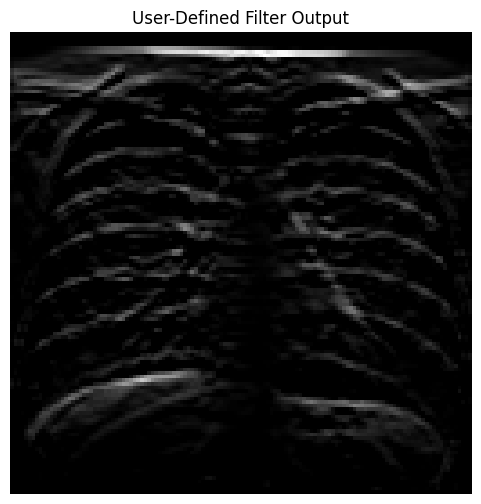

In [18]:
# Visualize user-defined filter output
plt.figure(figsize=(6, 6))

plt.imshow(filtered_output[0, :, :, 0], cmap="gray")
plt.title("User-Defined Filter Output")
plt.axis("off")

plt.show()

In [19]:
# Q1(b) — Built-in CNN Filters
# Conv2D
# ReLU
# MaxPooling
# Conv2D
# ReLU
# MaxPooling
# Flatten
# Dense latent layer
model = models.Sequential([
    
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(
        filters=8,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        name="conv1"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2),
        name="pool1"
    ),

    layers.Conv2D(
        filters=16,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        name="conv2"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2),
        name="pool2"
    ),

    layers.Flatten(name="flatten"),

    layers.Dense(
        32,
        activation="relu",
        name="latent_vector"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 32)             │       524,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,568 (2.00 MB)

 Trainable params: 525,568 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Q1(c) — Complexity
# Calculate convolution complexity
def conv_complexity(H, W, Cin, K, Cout):
    operations = H * W * Cin * K * K * Cout
    return operations


conv1_ops = conv_complexity(
    128, 128, 1, 3, 8
)

conv2_ops = conv_complexity(
    64, 64, 8, 3, 16
)

print("Conv1 operations:", conv1_ops)
print("Conv2 operations:", conv2_ops)

print("Total convolution operations:",
      conv1_ops + conv2_ops)

Conv1 operations: 1179648
Conv2 operations: 4718592
Total convolution operations: 5898240


In [21]:
# Display number of filters
print("Conv1 filters:", model.get_layer("conv1").filters)
print("Conv2 filters:", model.get_layer("conv2").filters)

print("Conv1 kernel size:",
      model.get_layer("conv1").kernel_size)

print("Conv2 kernel size:",
      model.get_layer("conv2").kernel_size)

Conv1 filters: 8
Conv2 filters: 16
Conv1 kernel size: (3, 3)
Conv2 kernel size: (3, 3)


In [25]:
# Q1(d) — Extract intermediate feature maps
# Create feature extraction model
feature_input = layers.Input(shape=(128, 128, 1))

conv1_output = model.get_layer("conv1")(feature_input)
pool1_output = model.get_layer("pool1")(conv1_output)
conv2_output = model.get_layer("conv2")(pool1_output)
pool2_output = model.get_layer("pool2")(conv2_output)
flatten_output = model.get_layer("flatten")(pool2_output)
latent_output = model.get_layer("latent_vector")(flatten_output)

feature_model = models.Model(
    inputs=feature_input,
    outputs=[
        conv1_output,
        pool1_output,
        conv2_output,
        pool2_output,
        flatten_output,
        latent_output
    ]
)

features = feature_model.predict(input_tensor)

conv1_features = features[0]
pool1_features = features[1]
conv2_features = features[2]
pool2_features = features[3]
flatten_features = features[4]
latent_vector = features[5]

print("Conv1:", conv1_features.shape)
print("Pool1:", pool1_features.shape)
print("Conv2:", conv2_features.shape)
print("Pool2:", pool2_features.shape)
print("Flatten:", flatten_features.shape)
print("Latent:", latent_vector.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
Conv1: (1, 128, 128, 8)
Pool1: (1, 64, 64, 8)
Conv2: (1, 64, 64, 16)
Pool2: (1, 32, 32, 16)
Flatten: (1, 16384)
Latent: (1, 32)


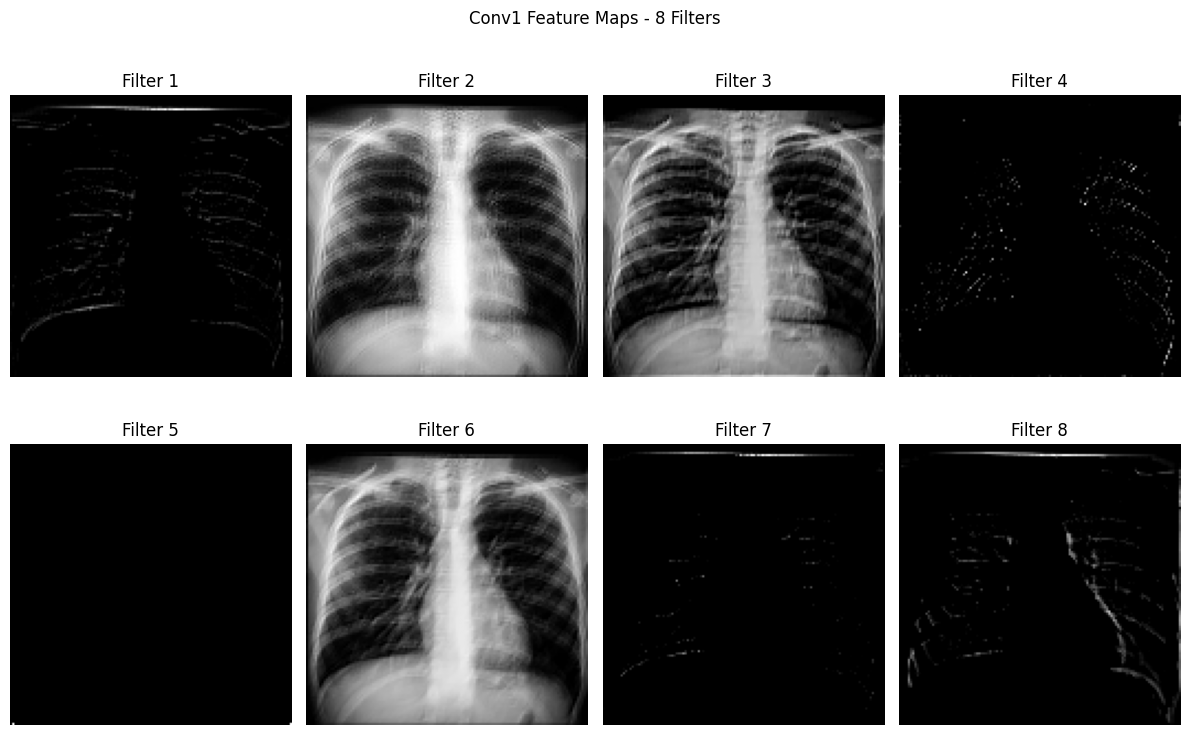

In [26]:
# Q1(e) — Visualize Conv1 feature maps
plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(conv1_features[0, :, :, i], cmap="gray")
    plt.title(f"Filter {i+1}")
    plt.axis("off")

plt.suptitle("Conv1 Feature Maps - 8 Filters")
plt.tight_layout()
plt.show()

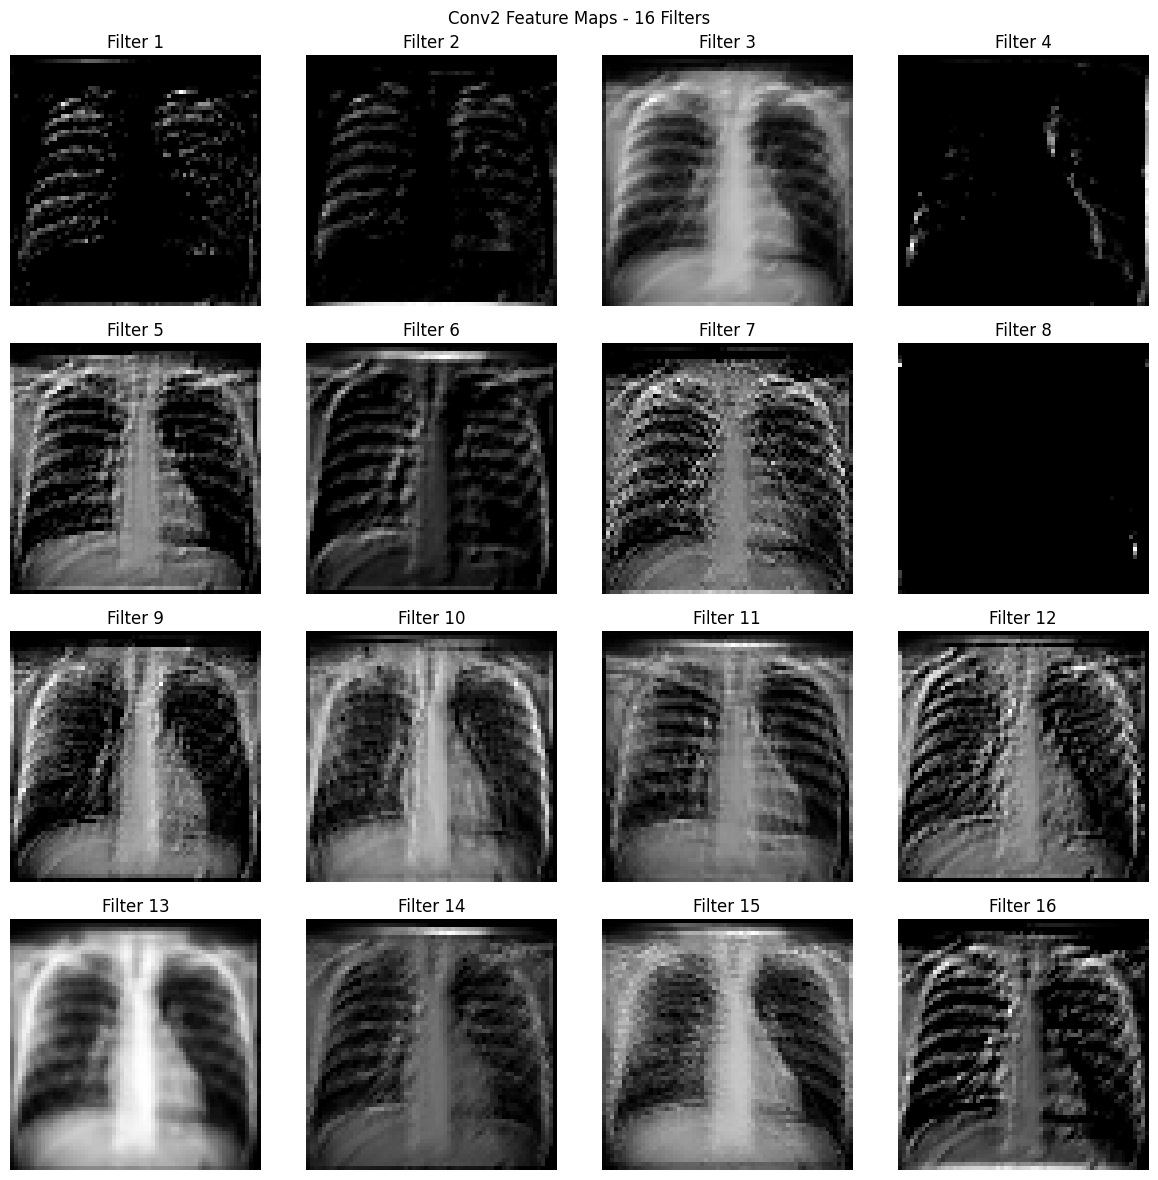

In [28]:
# Q1(g) — Visualize second convolution
plt.figure(figsize=(12, 12))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(conv2_features[0, :, :, i], cmap="gray")
    plt.title(f"Filter {i+1}")
    plt.axis("off")

plt.suptitle("Conv2 Feature Maps - 16 Filters")
plt.tight_layout()
plt.show()

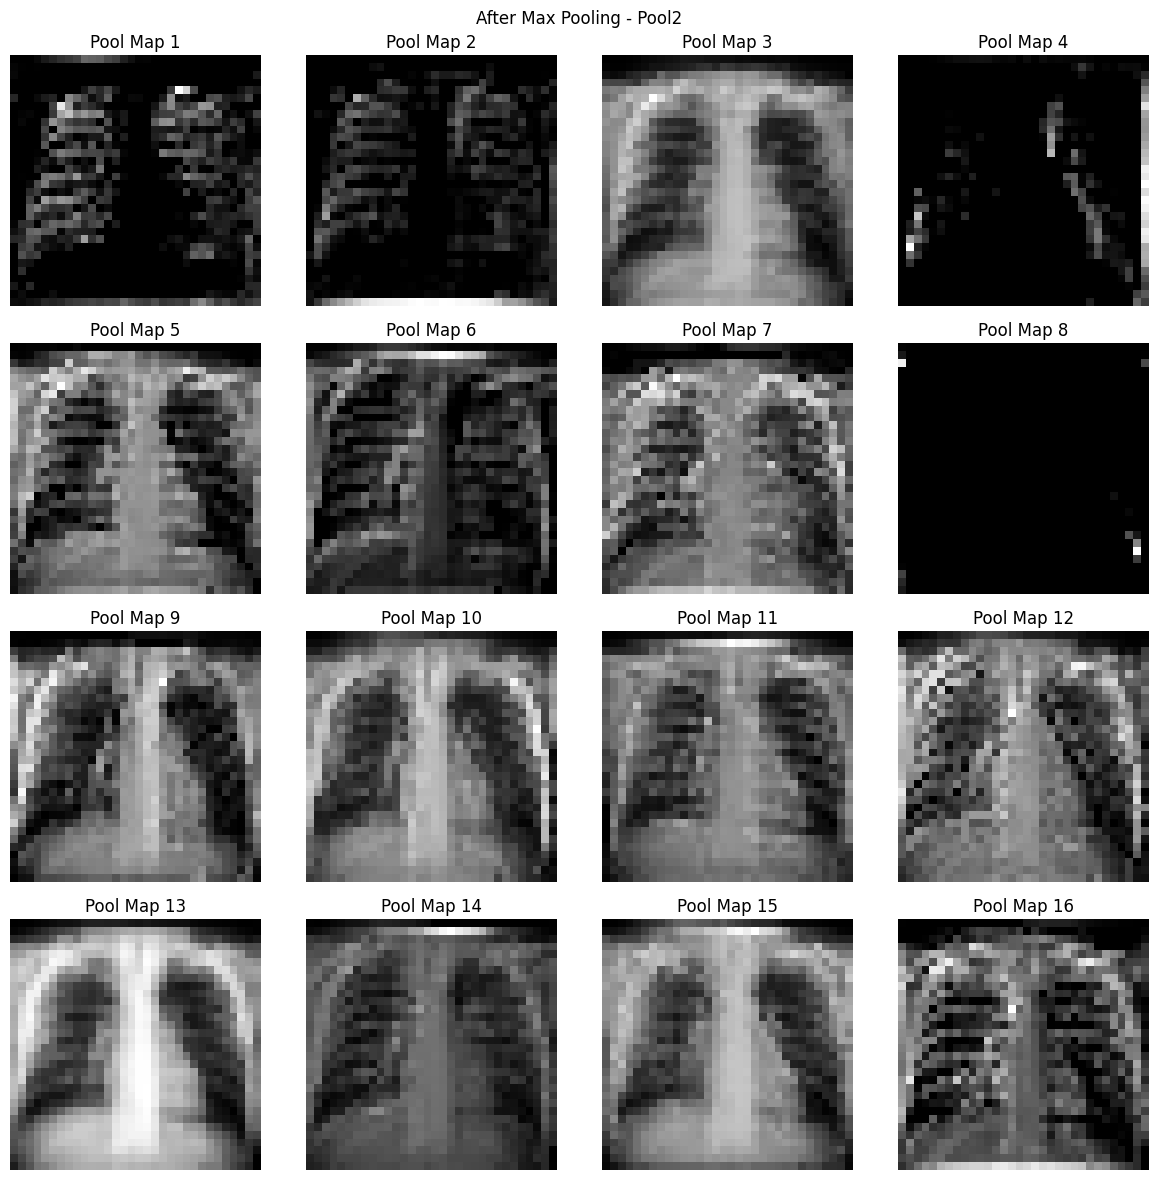

In [30]:
# Q1(h) — Visualize second pooling layer
plt.figure(figsize=(12, 12))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(pool2_features[0, :, :, i], cmap="gray")
    plt.title(f"Pool Map {i+1}")
    plt.axis("off")

plt.suptitle("After Max Pooling - Pool2")
plt.tight_layout()
plt.show()

In [31]:
# Q1(i) — Flattened representation
print("Flattened feature vector shape:",
      flatten_features.shape)

print("\nFirst 20 flattened values:")
print(flatten_features[0][:20])

Flattened feature vector shape: (1, 16384)

First 20 flattened values:
[0.         0.00012349 0.00103987 0.         0.00039333 0.00092535
 0.00010996 0.00020314 0.00082084 0.00024766 0.0013002  0.00057952
 0.00251358 0.00079951 0.00062349 0.0004917  0.         0.
 0.000787   0.        ]


In [32]:
# Q1(j) — Final latent vector
print("Latent vector shape:", latent_vector.shape)

print("\nLatent vector:")
print(latent_vector[0])

Latent vector shape: (1, 32)

Latent vector:
[0.1724888  0.32254156 0.22319609 0.0624658  0.23462479 0.
 0.17977707 0.12875815 0.08889328 0.42356625 0.         0.06984368
 0.         0.         0.15338609 0.33387402 0.         0.24569835
 0.05667262 0.11707668 0.15192793 0.04963429 0.         0.
 0.01622909 0.         0.14644328 0.0527329  0.23174217 0.
 0.         0.        ]


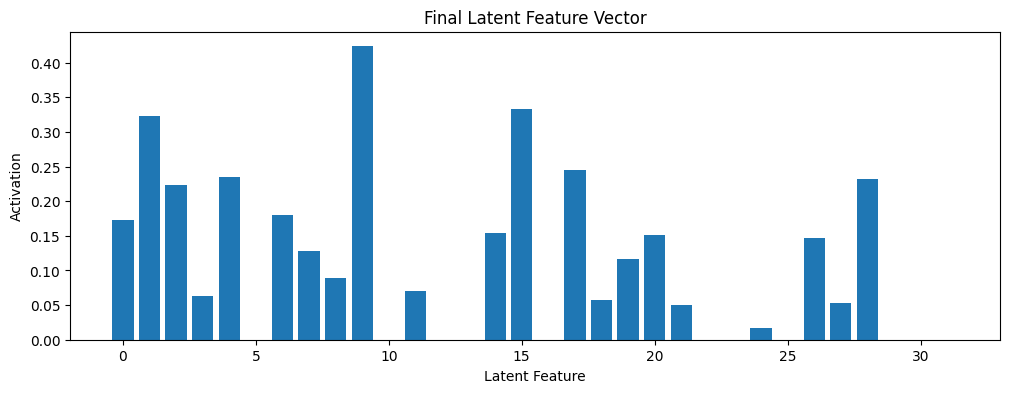

In [33]:
# Visualize latent vector
plt.figure(figsize=(12, 4))

plt.bar(
    range(32),
    latent_vector[0]
)

plt.xlabel("Latent Feature")
plt.ylabel("Activation")
plt.title("Final Latent Feature Vector")
plt.show()

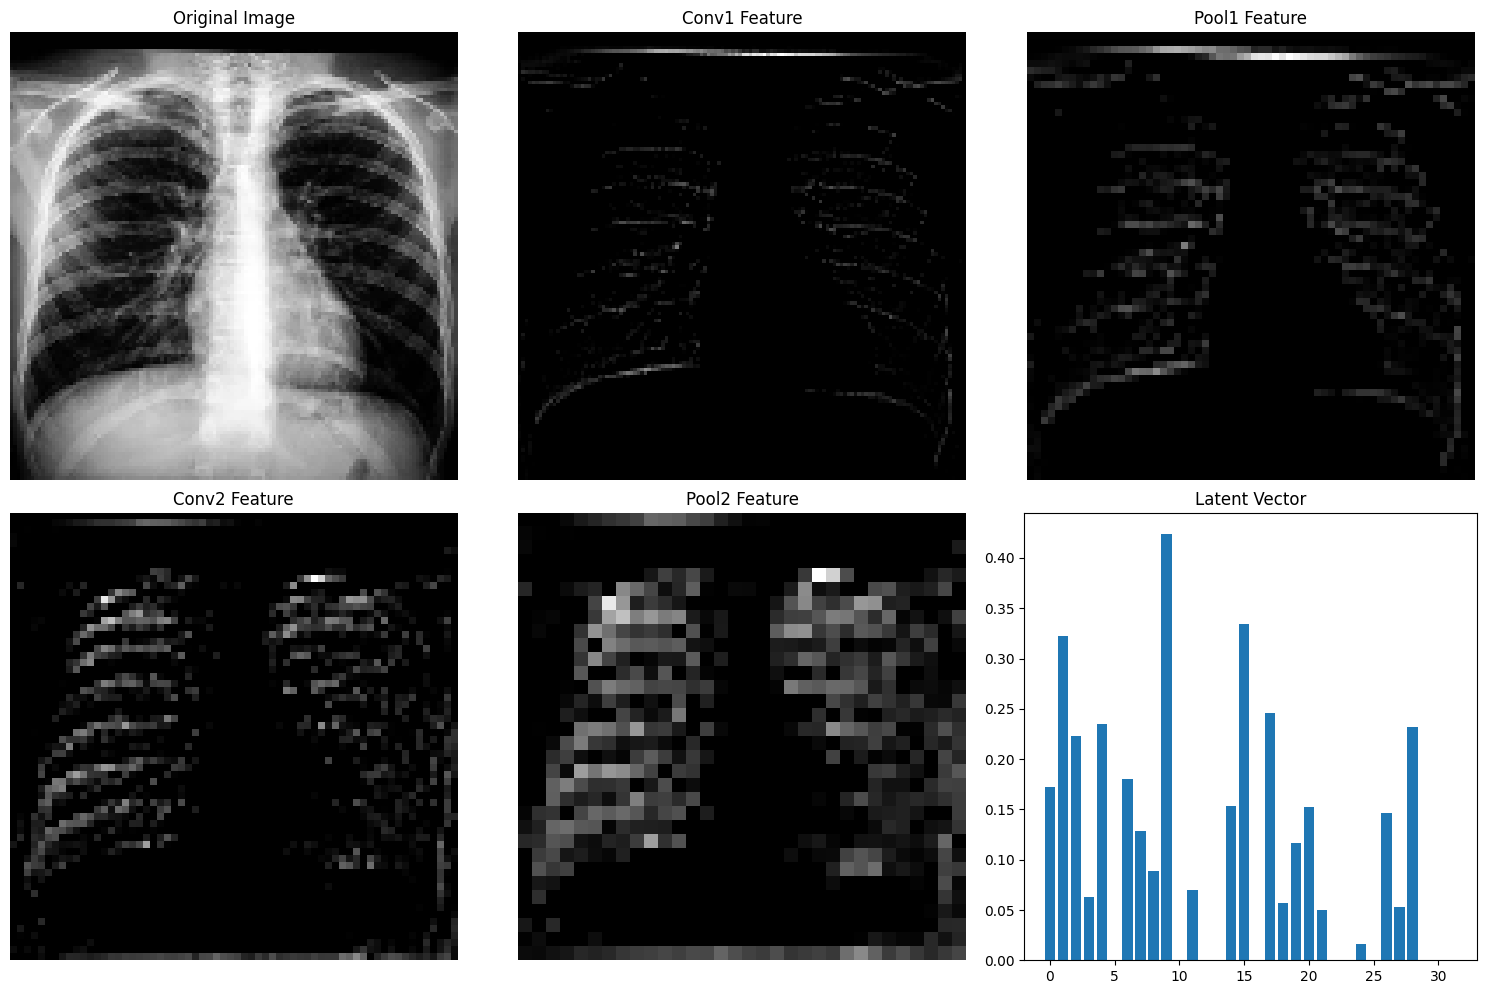

In [34]:
# Q1(k) — Complete visualization
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_normalized.squeeze(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(conv1_features[0, :, :, 0], cmap="gray")
plt.title("Conv1 Feature")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(pool1_features[0, :, :, 0], cmap="gray")
plt.title("Pool1 Feature")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(conv2_features[0, :, :, 0], cmap="gray")
plt.title("Conv2 Feature")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(pool2_features[0, :, :, 0], cmap="gray")
plt.title("Pool2 Feature")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.bar(range(32), latent_vector[0])
plt.title("Latent Vector")

plt.tight_layout()
plt.show()

In [55]:
# Q2 — Personal RGB Image
# Load personal RGB image
RGB_IMAGE_PATH = r"C:\Users\Neethu\Documents\AMI\WhatsApp Image 2026-09-07 at 19.37.33.jpeg"

rgb_img = image.load_img(
    RGB_IMAGE_PATH,
    color_mode="rgb",
    target_size=(128, 128)
)

rgb_array = image.img_to_array(rgb_img)

print("Personal RGB image shape:", rgb_array.shape)

Personal RGB image shape: (128, 128, 3)


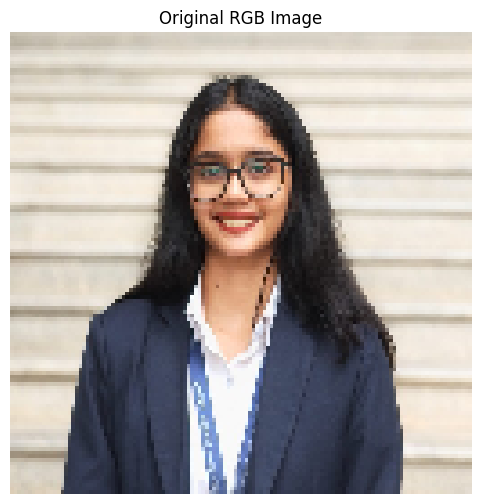

In [ ]:
# Display personal RGB image
plt.figure(figsize=(6, 6))

plt.imshow(rgb_array.astype("uint8"))
plt.title("Original Personal RGB Image")
plt.axis("off")

plt.show()

In [37]:
# Normalize RGB image
rgb_normalized = rgb_array / 255.0

rgb_input = np.expand_dims(
    rgb_normalized,
    axis=0
)

rgb_tensor = tf.convert_to_tensor(
    rgb_input,
    dtype=tf.float32
)

print("RGB tensor shape:", rgb_tensor.shape)

RGB tensor shape: (1, 128, 128, 3)


In [38]:
# Q2(a) — RGB CNN
# Create RGB CNN
rgb_model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(
        8,
        (3, 3),
        padding="same",
        activation="relu",
        name="rgb_conv1"
    ),

    layers.MaxPooling2D(
        (2, 2),
        name="rgb_pool1"
    ),

    layers.Conv2D(
        16,
        (3, 3),
        padding="same",
        activation="relu",
        name="rgb_conv2"
    ),

    layers.MaxPooling2D(
        (2, 2),
        name="rgb_pool2"
    ),

    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu",
        name="rgb_conv3"
    ),

    layers.MaxPooling2D(
        (2, 2),
        name="rgb_pool3"
    ),

    layers.Flatten(name="rgb_flatten"),

    layers.Dense(
        64,
        activation="relu",
        name="rgb_latent"
    )
])

rgb_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_conv1 (Conv2D)              │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rgb_pool1 (MaxPooling2D)        │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rgb_conv2 (Conv2D)              │ (None, 64, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rgb_pool2 (MaxPooling2D)        │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rgb_conv3 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rgb_pool3 (MaxPooling2D)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rgb_flatten (Flatten)           │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rgb_latent (Dense)              │ (None, 64)             │       524,352 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,384 (2.02 MB)

 Trainable params: 530,384 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# RGB Complexity
rgb_conv1_ops = conv_complexity(
    128, 128, 3, 3, 8
)

rgb_conv2_ops = conv_complexity(
    64, 64, 8, 3, 16
)

rgb_conv3_ops = conv_complexity(
    32, 32, 16, 3, 32
)

print("RGB Conv1 operations:", rgb_conv1_ops)
print("RGB Conv2 operations:", rgb_conv2_ops)
print("RGB Conv3 operations:", rgb_conv3_ops)

print(
    "Total RGB convolution operations:",
    rgb_conv1_ops +
    rgb_conv2_ops +
    rgb_conv3_ops
)

RGB Conv1 operations: 3538944
RGB Conv2 operations: 4718592
RGB Conv3 operations: 4718592
Total RGB convolution operations: 12976128


In [41]:
# Q2(c) — Extract RGB feature maps
rgb_feature_input = layers.Input(shape=(128, 128, 3))

rgb_conv1_output = rgb_model.get_layer("rgb_conv1")(rgb_feature_input)
rgb_pool1_output = rgb_model.get_layer("rgb_pool1")(rgb_conv1_output)
rgb_conv2_output = rgb_model.get_layer("rgb_conv2")(rgb_pool1_output)
rgb_pool2_output = rgb_model.get_layer("rgb_pool2")(rgb_conv2_output)
rgb_conv3_output = rgb_model.get_layer("rgb_conv3")(rgb_pool2_output)
rgb_pool3_output = rgb_model.get_layer("rgb_pool3")(rgb_conv3_output)
rgb_flatten_output = rgb_model.get_layer("rgb_flatten")(rgb_pool3_output)
rgb_latent_output = rgb_model.get_layer("rgb_latent")(rgb_flatten_output)

rgb_feature_model = models.Model(
    inputs=rgb_feature_input,
    outputs=[
        rgb_conv1_output,
        rgb_pool1_output,
        rgb_conv2_output,
        rgb_pool2_output,
        rgb_conv3_output,
        rgb_pool3_output,
        rgb_flatten_output,
        rgb_latent_output
    ]
)

rgb_features = rgb_feature_model.predict(rgb_tensor)

rgb_conv1 = rgb_features[0]
rgb_pool1 = rgb_features[1]
rgb_conv2 = rgb_features[2]
rgb_pool2 = rgb_features[3]
rgb_conv3 = rgb_features[4]
rgb_pool3 = rgb_features[5]
rgb_flatten = rgb_features[6]
rgb_latent = rgb_features[7]

print("Conv1:", rgb_conv1.shape)
print("Pool1:", rgb_pool1.shape)
print("Conv2:", rgb_conv2.shape)
print("Pool2:", rgb_pool2.shape)
print("Conv3:", rgb_conv3.shape)
print("Pool3:", rgb_pool3.shape)
print("Flatten:", rgb_flatten.shape)
print("Latent:", rgb_latent.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Conv1: (1, 128, 128, 8)
Pool1: (1, 64, 64, 8)
Conv2: (1, 64, 64, 16)
Pool2: (1, 32, 32, 16)
Conv3: (1, 32, 32, 32)
Pool3: (1, 16, 16, 32)
Flatten: (1, 8192)
Latent: (1, 64)


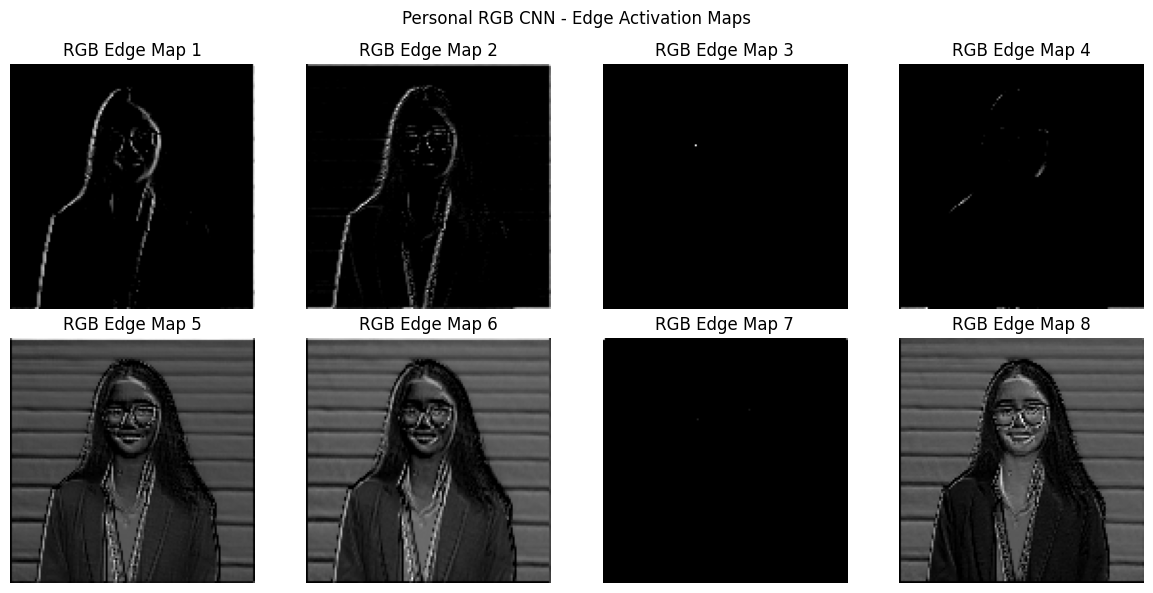

In [57]:
# Q2(d) — Edge features from the personal RGB image
# Each filter output is a single-channel activation map, shown in grayscale.
plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(rgb_conv1[0, :, :, i], cmap="gray")
    plt.title(f"RGB Edge Map {i+1}")
    plt.axis("off")

plt.suptitle("Personal RGB CNN - Edge Activation Maps")
plt.tight_layout()
plt.show()

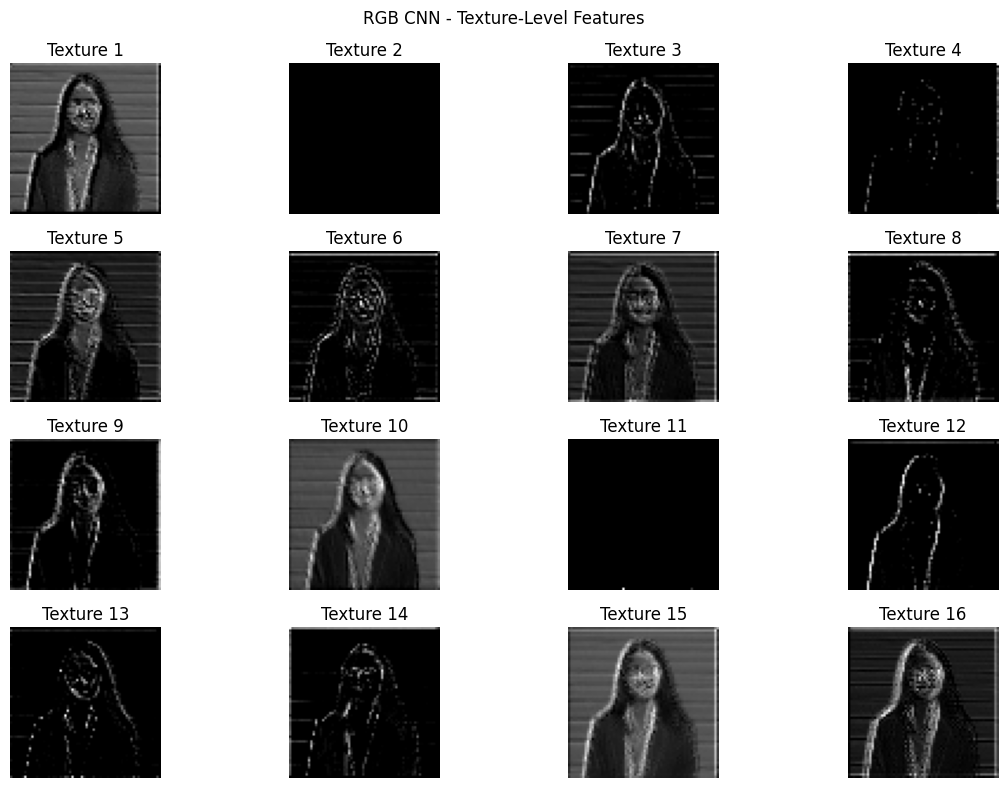

In [ ]:
# Q2(e) — Texture features from the personal RGB image
# Each filter output is a single-channel activation map, shown in grayscale.
plt.figure(figsize=(12, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(rgb_conv2[0, :, :, i], cmap="gray")
    plt.title(f"RGB Texture Map {i+1}")
    plt.axis("off")

plt.suptitle("Personal RGB CNN - Texture Activation Maps")
plt.tight_layout()
plt.show()

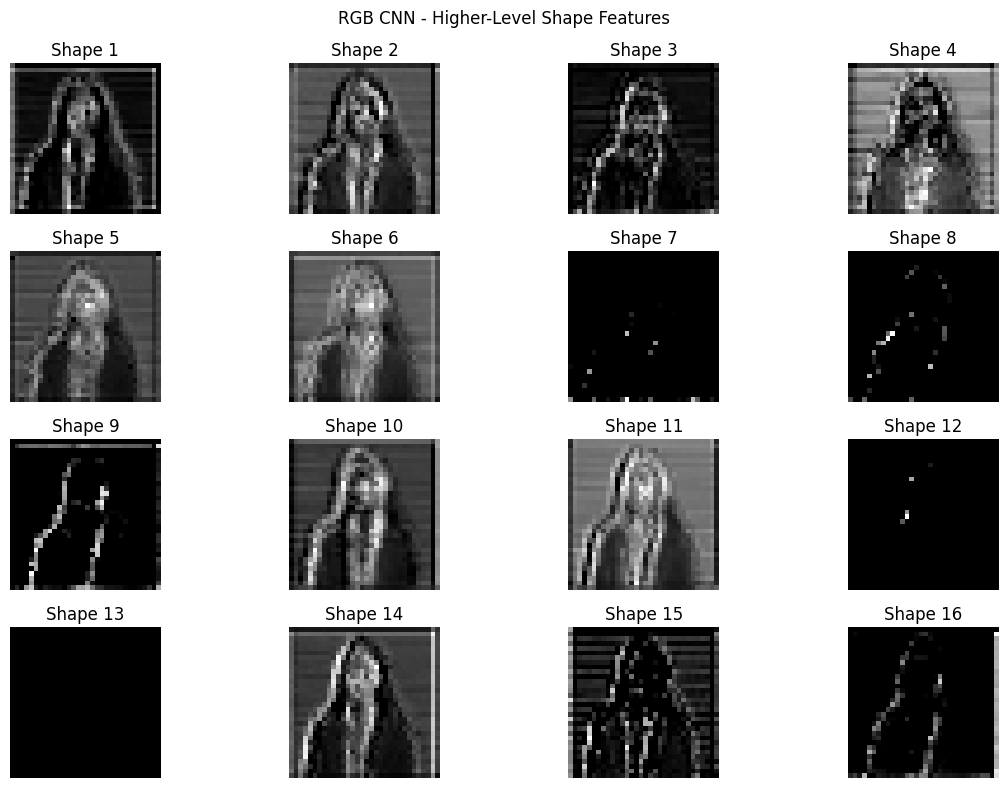

In [ ]:
# Q2(f) — Shape features from the personal RGB image
# Each filter output is a single-channel activation map, shown in grayscale.
plt.figure(figsize=(12, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(rgb_conv3[0, :, :, i], cmap="gray")
    plt.title(f"RGB Shape Map {i+1}")
    plt.axis("off")

plt.suptitle("Personal RGB CNN - Shape Activation Maps")
plt.tight_layout()
plt.show()

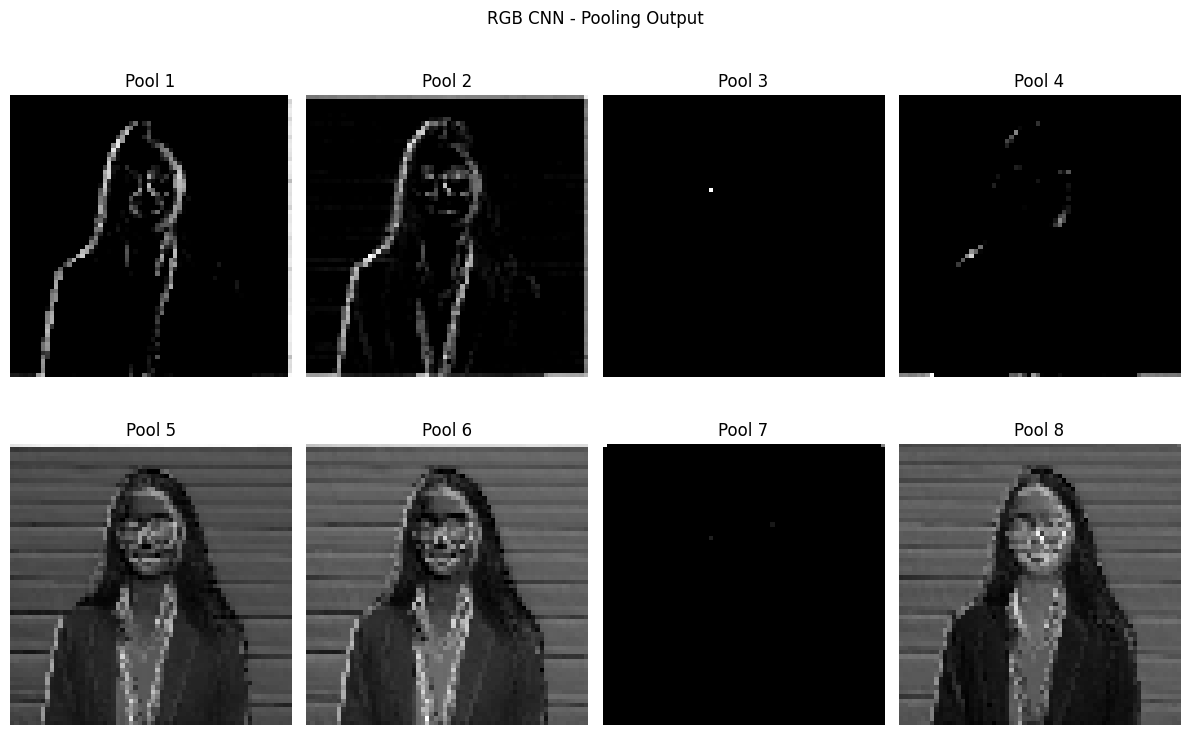

In [ ]:
# Q2(g) — Pooling output from the personal RGB image
# Pooling outputs are single-channel activation maps, shown in grayscale.
plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(rgb_pool1[0, :, :, i], cmap="gray")
    plt.title(f"RGB Pool Map {i+1}")
    plt.axis("off")

plt.suptitle("Personal RGB CNN - Pooling Activation Maps")
plt.tight_layout()
plt.show()

In [46]:
# Q2(h) — Flattened representation
print("Flattened feature representation:")
print("Shape:", rgb_flatten.shape)

print("\nFirst 20 values:")
print(rgb_flatten[0][:20])

Flattened feature representation:
Shape: (1, 8192)

First 20 values:
[0.0900598  0.07153771 0.01032834 0.0461189  0.07701328 0.13225062
 0.         0.         0.01323111 0.06453985 0.0992641  0.
 0.         0.08809295 0.03720811 0.00312555 0.05381842 0.0093464
 0.         0.01971316]


In [47]:
# Q2(i) — Final latent representation
print("RGB Latent Vector Shape:")
print(rgb_latent.shape)

print("\nRGB Latent Vector:")
print(rgb_latent[0])

RGB Latent Vector Shape:
(1, 64)

RGB Latent Vector:
[0.         0.         0.         0.         0.05186738 0.
 0.07138516 0.04876546 0.05352312 0.         0.11739893 0.08961137
 0.01954931 0.         0.00364711 0.         0.         0.08945645
 0.10789625 0.03823739 0.00338619 0.08885402 0.         0.06412364
 0.01978895 0.         0.000348   0.01403445 0.         0.01999182
 0.11473686 0.         0.         0.         0.07771201 0.10859076
 0.         0.0721836  0.         0.         0.01598587 0.01411553
 0.0347349  0.0590294  0.         0.01695535 0.         0.07818349
 0.01616235 0.12787265 0.         0.06357975 0.05114332 0.
 0.         0.04285998 0.         0.00744359 0.         0.
 0.10917547 0.         0.01632176 0.0346189 ]


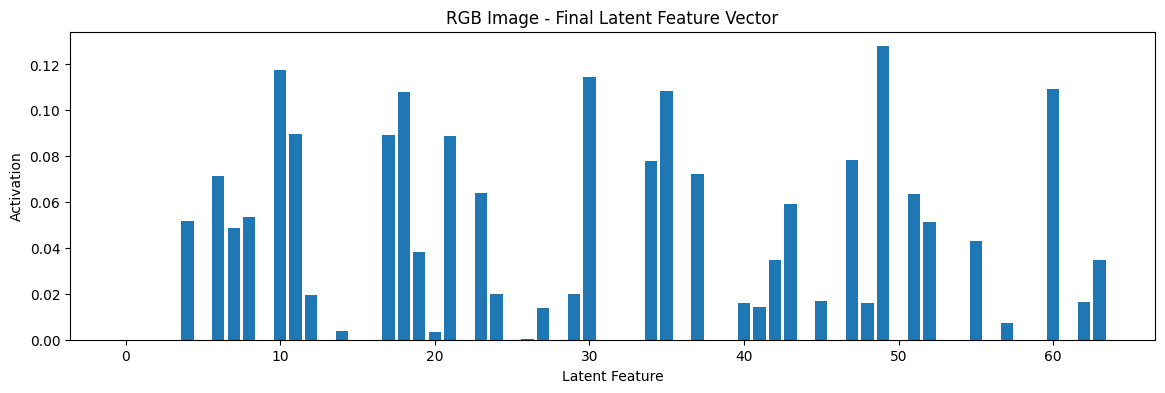

In [48]:
# Visualize RGB latent vector
plt.figure(figsize=(14, 4))

plt.bar(
    range(64),
    rgb_latent[0]
)

plt.xlabel("Latent Feature")
plt.ylabel("Activation")
plt.title("RGB Image - Final Latent Feature Vector")

plt.show()

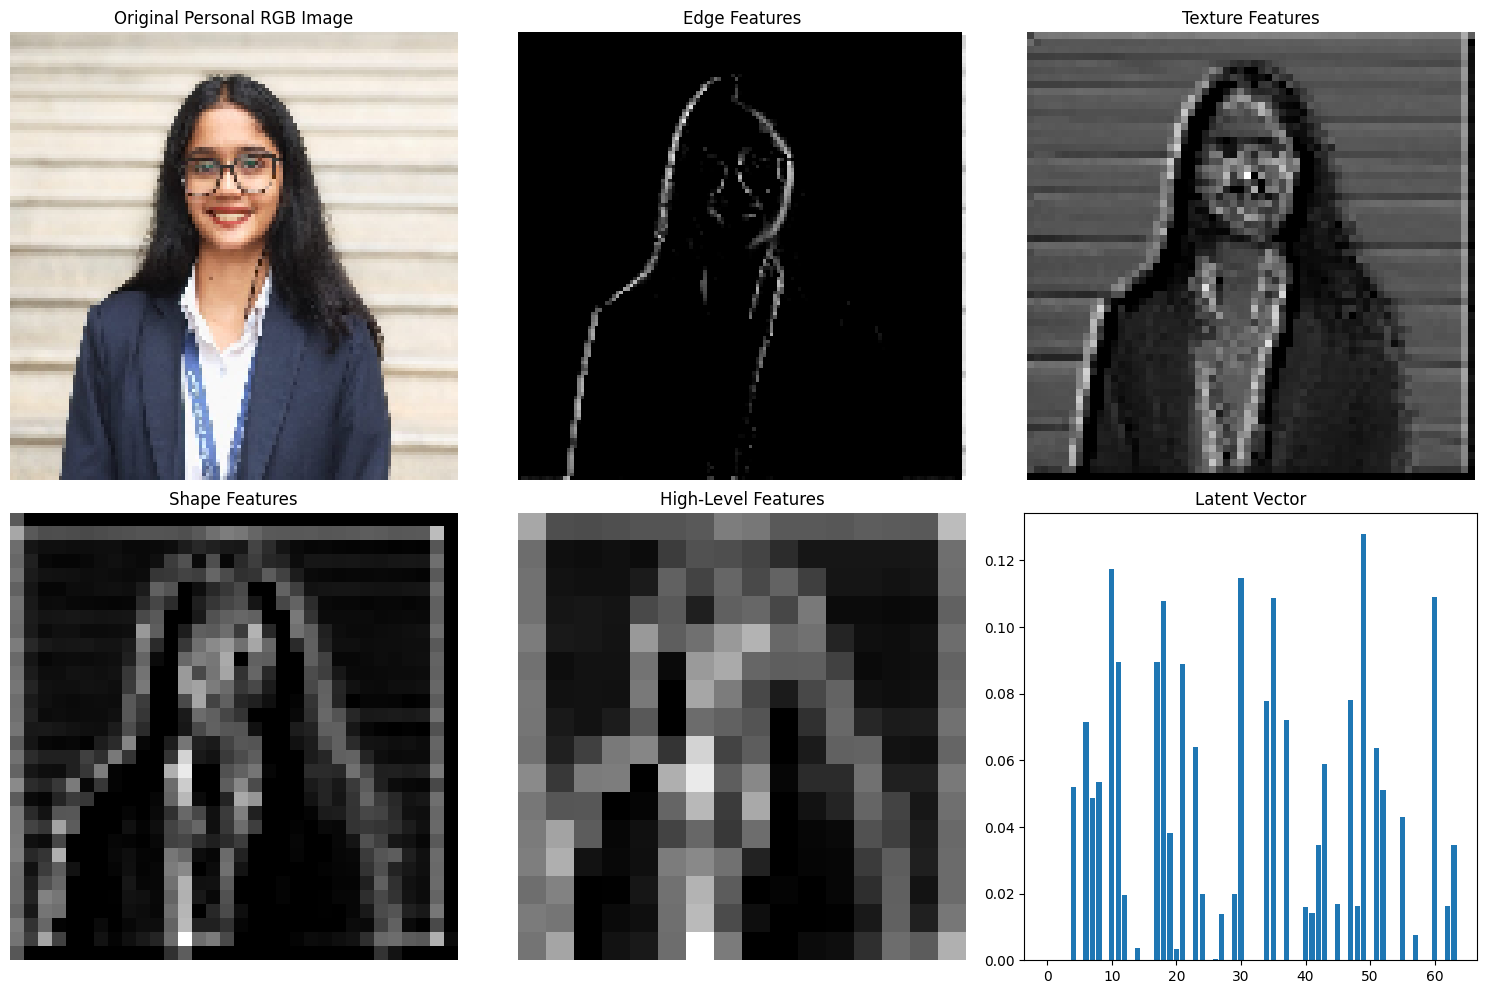

In [58]:
# Q2(j) — Personal RGB comparison visualization
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(rgb_normalized)
plt.title("Original Personal RGB Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(rgb_conv1[0, :, :, 0], cmap="gray")
plt.title("Edge Features")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(rgb_conv2[0, :, :, 0], cmap="gray")
plt.title("Texture Features")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(rgb_conv3[0, :, :, 0], cmap="gray")
plt.title("Shape Features")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(rgb_pool3[0, :, :, 0], cmap="gray")
plt.title("High-Level Features")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.bar(range(64), rgb_latent[0])
plt.title("Latent Vector")

plt.tight_layout()
plt.show()

In [50]:
# Q2(k) — Complexity comparison
print("========== COMPLEXITY COMPARISON ==========")

print("\nGRAYSCALE CNN")
print("Number of filters:")
print("Conv1 = 8")
print("Conv2 = 16")

print("\nRGB CNN")
print("Number of filters:")
print("Conv1 = 8")
print("Conv2 = 16")
print("Conv3 = 32")

print("\nGRAYSCALE TOTAL OPERATIONS:")
print(conv1_ops + conv2_ops)

print("\nRGB TOTAL OPERATIONS:")
print(rgb_conv1_ops + rgb_conv2_ops + rgb_conv3_ops)

========== COMPLEXITY COMPARISON ==========

GRAYSCALE CNN
Number of filters:
Conv1 = 8
Conv2 = 16

RGB CNN
Number of filters:
Conv1 = 8
Conv2 = 16
Conv3 = 32

GRAYSCALE TOTAL OPERATIONS:
5898240

RGB TOTAL OPERATIONS:
12976128


In [51]:
print("""
CNN FEATURE EXTRACTION COMPARISON

---------------------------------------------------------
Stage             Grayscale CNN       RGB CNN
---------------------------------------------------------
Input              128×128×1          128×128×3

Conv 1             8 filters           8 filters
                   Edge features       Edge features

Pooling            2×2                 2×2

Conv 2             16 filters          16 filters
                   Texture features    Texture features

Pooling            2×2                 2×2

Conv 3             --                  32 filters
                                       Shape features

Pooling            --                  2×2

Latent Vector      32 values           64 values
---------------------------------------------------------
""")


CNN FEATURE EXTRACTION COMPARISON

---------------------------------------------------------
Stage             Grayscale CNN       RGB CNN
---------------------------------------------------------
Input              128×128×1          128×128×3

Conv 1             8 filters           8 filters
                   Edge features       Edge features

Pooling            2×2                 2×2

Conv 2             16 filters          16 filters
                   Texture features    Texture features

Pooling            2×2                 2×2

Conv 3             --                  32 filters
                                       Shape features

Pooling            --                  2×2

Latent Vector      32 values           64 values
---------------------------------------------------------



## Interpretation

- The medical X-ray is loaded as a grayscale image with one channel.
- The personal image is loaded as an RGB image with three color channels.
- Both images are resized and normalized for CNN processing.
- The user-defined filter detects basic edges and patterns in the medical image.
- The first convolution layer extracts simple features such as edges and lines.
- Pooling reduces the feature-map size while retaining important information.
- The second convolution layer extracts detailed textures and patterns.
- The deeper convolution layers extract higher-level shapes and structures.
- Flattening converts the feature maps into a one-dimensional feature vector.
- Each latent vector represents important image features in a compact form.
- The RGB CNN processes the personal image using its three color channels.
- Early CNN layers detect edges and simple patterns.
- Middle CNN layers extract texture and local patterns.
- Deeper CNN layers extract shapes and structural features.
- Increasing the number of filters increases CNN computational complexity.
- Overall, CNN gradually transforms both images into meaningful latent feature representations.